# A/B-тест рекламной кампании

**Задача.** Компания запустила рекламную кампанию. Одним пользователям показывали рекламу продукта (`ad`), другим — нейтральное общественное объявление (PSA, `psa`). Нужно понять, **действительно ли реклама увеличила число покупок и насколько**.

**Данные:** 588 101 пользователь. Для каждого известно:

| Колонка | Описание |
|---|---|
| `user_id` | ID пользователя |
| `test_group` | `ad` — видел рекламу, `psa` — видел нейтральное объявление (контроль) |
| `converted` | совершил ли покупку |
| `total_ads` | сколько всего объявлений увидел |
| `most_ads_day` | день недели, когда увидел больше всего объявлений |
| `most_ads_hour` | час, в который увидел больше всего объявлений |

**Основная метрика:** конверсия в покупку (`converted`).

**Гипотезы:**
- H0: конверсия в группах `ad` и `psa` одинакова;
- H1: конверсия различается.

Уровень значимости α = 0.05 (двусторонний тест).

## 1. Загрузка и проверка данных

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
RNG = np.random.default_rng(42)
ALPHA = 0.05
Z = stats.norm.ppf(1 - ALPHA / 2)

df = pd.read_csv('data/marketing_AB.csv')
df = df.drop(columns=['Unnamed: 0'])                       
df.columns = [c.replace(' ', '_') for c in df.columns] 
df['converted'] = df['converted'].astype(int)
print(df.shape)
df.head()

(588101, 6)


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,0,130,Monday,20
1,1119715,ad,0,93,Tuesday,22
2,1144181,ad,0,21,Tuesday,18
3,1435133,ad,0,355,Tuesday,10
4,1015700,ad,0,276,Friday,14


In [2]:
print('Пропуски:', int(df.isna().sum().sum()))
print('Дубликаты user_id:', int(df['user_id'].duplicated().sum()))
print()
sizes = df['test_group'].value_counts()
print(pd.DataFrame({'пользователей': sizes, 'доля': (sizes / sizes.sum()).round(3)}))

Пропуски: 0
Дубликаты user_id: 0

            пользователей  доля
test_group                     
ad                 564577  0.96
psa                 23524  0.04


Пропусков и дубликатов нет, каждый пользователь встречается один раз. Группы **сильно несбалансированы**: 96% пользователей увидели рекламу и только 4% — нейтральное объявление. Для рекламных экспериментов это нормально: контрольную группу делают небольшой, чтобы не терять потенциальные продажи. Цена такого дизайна — более широкий доверительный интервал, поэтому далее оценим чувствительность теста.

## 2. Какой эффект тест способен заметить (MDE)

Минимальный обнаружимый эффект при α = 0.05 и мощности 80%. Из-за маленькой контрольной группы он будет больше, чем при равных группах.

In [3]:
n_ad = (df['test_group'] == 'ad').sum()
n_psa = (df['test_group'] == 'psa').sum()
p_base = df.loc[df['test_group'] == 'psa', 'converted'].mean()

z_total = Z + stats.norm.ppf(0.8)
mde = z_total * np.sqrt(p_base * (1 - p_base) * (1 / n_ad + 1 / n_psa))
print(f'Базовая конверсия (PSA): {p_base:.2%}')
print(f'MDE: {mde * 100:.2f} п.п. ({mde / p_base:.0%} относительно базы)')

Базовая конверсия (PSA): 1.79%
MDE: 0.25 п.п. (14% относительно базы)


Тест способен надёжно заметить разницу в конверсии от 0.25 п.п. Дальше сравним это с реально наблюдаемым эффектом.

## 3. Сопоставимость групп

Прежде чем сравнивать конверсию, проверим, похожи ли группы по тому, сколько и когда пользователи видели объявления. При случайном распределении они должны быть близки.

In [4]:
balance = df.groupby('test_group').agg(
    среднее_показов=('total_ads', 'mean'),
    медиана_показов=('total_ads', 'median'),
    средний_час=('most_ads_hour', 'mean'),
).round(2)
print(balance)

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_share = pd.crosstab(df['most_ads_day'], df['test_group'], normalize='columns').reindex(order)
print('\nДоля пользователей по дню максимального числа показов:')
print((day_share * 100).round(1))

chi2, p_day, *_ = stats.chi2_contingency(pd.crosstab(df['most_ads_day'], df['test_group']))
print(f'\nРаспределение по дням: chi2 p-value = {p_day:.1e}')

            среднее_показов  медиана_показов  средний_час
test_group                                               
ad                    24.82             13.0        14.48
psa                   24.76             12.0        14.30

Доля пользователей по дню максимального числа показов:
test_group      ad   psa
most_ads_day            
Monday        14.8  14.9
Tuesday       13.2  12.4
Wednesday     13.7  14.8
Thursday      14.0  16.6
Friday        15.7  16.2
Saturday      14.0  12.1
Sunday        14.6  13.0

Распределение по дням: chi2 p-value = 4.8e-48


Средние значения почти совпадают (≈24.8 показа у обеих групп), но формальные тесты на таком большом объёме данных замечают даже мелкие отличия: например, доля пользователей с максимумом показов в четверг — 14.0% в `ad` и 16.6% в `psa`. Отличия небольшие, но они могут влиять на конверсию, ведь конверсия зависит от дня и времени. Поэтому ниже сделаем **проверку на устойчивость**: пересчитаем эффект с поправкой на день и время суток.

## 4. Основной результат: влияние рекламы на конверсию

**z-тест для двух долей**, доверительный интервал разницы и бутстреп.

In [5]:
g = df.groupby('test_group')['converted'].agg(['sum', 'count'])
x_psa, n_psa = g.loc['psa']
x_ad, n_ad = g.loc['ad']
p_psa, p_ad = x_psa / n_psa, x_ad / n_ad

p_pool = (x_psa + x_ad) / (n_psa + n_ad)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_psa + 1 / n_ad))
z_stat = (p_ad - p_psa) / se_pool
p_value = 2 * stats.norm.sf(abs(z_stat))

diff = p_ad - p_psa
se = np.sqrt(p_psa * (1 - p_psa) / n_psa + p_ad * (1 - p_ad) / n_ad)
ci = (diff - Z * se, diff + Z * se)

summary = pd.DataFrame({
    'конверсия': [f'{p_psa:.3%}', f'{p_ad:.3%}'],
    'покупок': [int(x_psa), int(x_ad)],
    'пользователей': [int(n_psa), int(n_ad)],
}, index=['psa (контроль)', 'ad (реклама)'])
print(summary, '\n')
print(f'Разница: {diff * 100:.2f} п.п., 95% ДИ [{ci[0] * 100:.2f}; {ci[1] * 100:.2f}] п.п.')
print(f'Относительный прирост (lift): {diff / p_psa:+.1%}')
print(f'z = {z_stat:.2f}, p-value = {p_value:.1e}')

               конверсия  покупок  пользователей
psa (контроль)    1.785%      420          23524
ad (реклама)      2.555%    14423         564577 

Разница: 0.77 п.п., 95% ДИ [0.60; 0.94] п.п.
Относительный прирост (lift): +43.1%
z = 7.37, p-value = 1.7e-13


In [ ]:
B = 20000
boot_psa = RNG.binomial(n_psa, p_psa, B) / n_psa
boot_ad = RNG.binomial(n_ad, p_ad, B) / n_ad
boot_diff = (boot_ad - boot_psa) * 100
boot_lift = (boot_ad / boot_psa - 1) * 100

lo, hi = np.percentile(boot_diff, [2.5, 97.5])
llo, lhi = np.percentile(boot_lift, [2.5, 97.5])
print(f'Бутстреп, разница: 95% ДИ [{lo:.2f}; {hi:.2f}] п.п.')
print(f'Бутстреп, lift: 95% ДИ [{llo:.0f}%; {lhi:.0f}%]')
print(f'Доля бутстреп-выборок с отрицательным эффектом: {(boot_diff <= 0).mean():.2%}')

Бутстреп, разница: 95% ДИ [0.60; 0.94] п.п.
Бутстреп, lift: 95% ДИ [31%; 58%]
Доля бутстреп-выборок с отрицательным эффектом: 0.00%


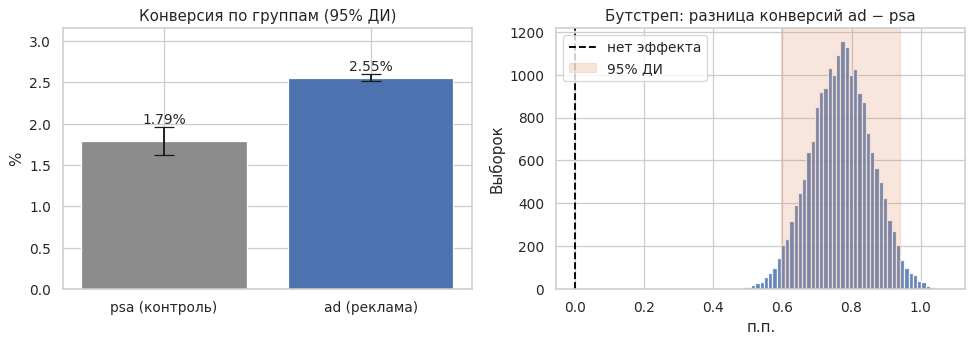

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# конверсия по группам с 95% ДИ
groups = ['psa (контроль)', 'ad (реклама)']
rates = np.array([p_psa, p_ad]) * 100
errs = Z * np.array([np.sqrt(p_psa * (1 - p_psa) / n_psa), np.sqrt(p_ad * (1 - p_ad) / n_ad)]) * 100
axes[0].bar(groups, rates, yerr=errs, capsize=8, color=['#8C8C8C', '#4C72B0'])
for i, r in enumerate(rates):
    axes[0].text(i, r + errs[i] + 0.05, f'{r:.2f}%', ha='center', fontsize=11)
axes[0].set(title='Конверсия по группам (95% ДИ)', ylabel='%', ylim=(0, rates.max() + 0.6))

# распределение разницы
axes[1].hist(boot_diff, bins=60, color='#4C72B0', alpha=0.85)
axes[1].axvline(0, color='black', ls='--', lw=1.5, label='нет эффекта')
axes[1].axvspan(lo, hi, color='#DD8452', alpha=0.2, label='95% ДИ')
axes[1].set(title='Бутстреп: разница конверсий ad − psa', xlabel='п.п.', ylabel='Выборок')
axes[1].legend()
plt.tight_layout()
fig.savefig('images/conversion_and_bootstrap.png', dpi=120)
plt.show()

**Вывод.** Конверсия в группе с рекламой — 2.55% против 1.79% в контроле. Разница **+0.77 п.п.**, что означает **рост конверсии на 43%**. Различие статистически значимо (p ≈ 10⁻¹³), доверительный интервал целиком лежит выше нуля, а наблюдаемый эффект втрое превышает MDE (0.25 п.п.): тест был достаточно чувствителен. Бутстреп даёт тот же результат.

## 5. Что это значит в штуках и деньгах

Статистическая значимость сама по себе не отвечает на бизнес-вопрос. Переведём разницу конверсий в **дополнительные покупки**: сколько из покупок в группе с рекламой не случились бы без неё.

In [8]:
extra_per_1000 = diff * 1000
extra_total = diff * n_ad
extra_lo, extra_hi = ci[0] * n_ad, ci[1] * n_ad
share_attr = extra_total / x_ad

print(f'Дополнительных покупок на 1 000 показанных пользователей: {extra_per_1000:.1f}')
print(f'Всего дополнительных покупок: ~{extra_total:,.0f} (95% ДИ {extra_lo:,.0f} – {extra_hi:,.0f})')
print(f'Доля покупок в группе ad, обязанная рекламе: {share_attr:.0%} из {int(x_ad):,}')

Дополнительных покупок на 1 000 показанных пользователей: 7.7
Всего дополнительных покупок: ~4,343 (95% ДИ 3,360 – 5,326)
Доля покупок в группе ad, обязанная рекламе: 30% из 14,423


Из ~14.4 тыс. покупок в группе с рекламой около **30% (≈4.3 тыс.) — прямой результат рекламы**, остальные пользователи купили бы и без неё. Оценить рентабельность (ROI) по этим данным нельзя: нет стоимости показов и выручки с покупки. Но для принятия решения достаточно простого правила: кампания окупается, если **маржа с 7.7 доп. покупок на 1 000 пользователей больше стоимости 1 000 показов**.

## 6. Проверка на устойчивость

В разделе 3 мы заметили небольшие перекосы между группами по дню недели и времени суток. Проверим, не влияют ли они на вывод: сравним группы **внутри одинаковых сегментов** (день недели × время суток) и усредним разницу с весами группы `ad`.

In [ ]:
df['time_of_day'] = pd.cut(df['most_ads_hour'], [-1, 5, 11, 17, 23],
                           labels=['ночь 0–5', 'утро 6–11', 'день 12–17', 'вечер 18–23'])
s = (df.groupby(['most_ads_day', 'time_of_day', 'test_group'], observed=True)['converted']
       .agg(['mean', 'count']).unstack().dropna())
w = s[('count', 'ad')] / s[('count', 'ad')].sum()
adj_diff = (w * (s[('mean', 'ad')] - s[('mean', 'psa')])).sum()

c_ad, c_psa = s[('count', 'ad')].values, s[('count', 'psa')].values
m_ad, m_psa = s[('mean', 'ad')].values, s[('mean', 'psa')].values
boots = []
for _ in range(5000):
    a = RNG.binomial(c_ad, m_ad) / c_ad
    b = RNG.binomial(c_psa, m_psa) / c_psa
    boots.append((w.values * (a - b)).sum())
alo, ahi = np.percentile(boots, [2.5, 97.5])

print(f'Сырая разница:             {diff * 100:.2f} п.п.')
print(f'С поправкой на сегменты:   {adj_diff * 100:.2f} п.п., 95% ДИ [{alo * 100:.2f}; {ahi * 100:.2f}]')

Сырая разница:             0.77 п.п.
С поправкой на сегменты:   0.78 п.п., 95% ДИ [0.60; 0.95]


Поправка почти ничего не меняет (0.77 → 0.78 п.п.): дисбаланс по дню и времени суток на результат не влияет. Вывод устойчив.

## 7. Когда реклама работает лучше: день недели и время суток

Посмотрим, как разница конверсий (ad − psa) меняется по сегментам. В контрольной группе мало пользователей, поэтому интервалы по сегментам широкие, и к отдельным цифрам надо относиться осторожно: чем больше сегментов, тем выше шанс случайной «находки».

In [10]:
def segment_effect(col, order_):
    rows = []
    for key in order_:
        d = df[df[col] == key]
        a, b = d[d['test_group'] == 'ad']['converted'], d[d['test_group'] == 'psa']['converted']
        dd = a.mean() - b.mean()
        se_ = np.sqrt(a.mean() * (1 - a.mean()) / len(a) + b.mean() * (1 - b.mean()) / len(b))
        rows.append({'сегмент': key, 'ad, %': a.mean() * 100, 'psa, %': b.mean() * 100,
                     'разница, п.п.': dd * 100, 'ДИ −, п.п.': (dd - Z * se_) * 100,
                     'ДИ +, п.п.': (dd + Z * se_) * 100, 'psa, польз.': len(b)})
    return pd.DataFrame(rows).set_index('сегмент')

day_en = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_day = segment_effect('most_ads_day', day_en)
by_day.index = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
by_time = segment_effect('time_of_day', list(df['time_of_day'].cat.categories))
print(by_day.round(2), '\n')
print(by_time.round(2))

    ad, %  psa, %  разница, п.п.  ДИ −, п.п.  ДИ +, п.п.  psa, польз.
Пн   3.32    2.26           1.07        0.56        1.57         3502
Вт   3.04    1.44           1.60        1.15        2.05         2907
Ср   2.54    1.58           0.96        0.53        1.39         3490
Чт   2.16    2.02           0.14       -0.31        0.59         3905
Пт   2.25    1.63           0.62        0.20        1.03         3803
Сб   2.13    1.40           0.73        0.29        1.17         2858
Вс   2.46    2.06           0.40       -0.11        0.92         3059 

             ad, %  psa, %  разница, п.п.  ДИ −, п.п.  ДИ +, п.п.  psa, польз.
сегмент                                                                       
ночь 0–5      1.35    0.14           1.21        0.90        1.52          735
утро 6–11     2.12    1.26           0.86        0.56        1.16         5727
день 12–17    2.77    2.02           0.75        0.48        1.02        10914
вечер 18–23   2.74    2.07           0.68  

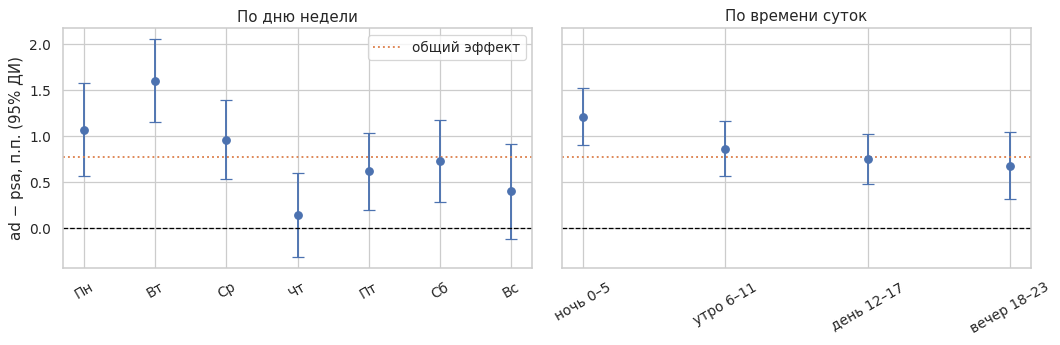

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, tbl, title in [(axes[0], by_day, 'По дню недели'), (axes[1], by_time, 'По времени суток')]:
    y = tbl['разница, п.п.'].values
    err = np.vstack([y - tbl['ДИ −, п.п.'].values, tbl['ДИ +, п.п.'].values - y])
    ax.errorbar(range(len(tbl)), y, yerr=err, fmt='o', color='#4C72B0', capsize=5)
    ax.axhline(0, color='black', ls='--', lw=1)
    ax.axhline(diff * 100, color='#DD8452', ls=':', lw=1.5, label='общий эффект')
    ax.set_xticks(range(len(tbl))); ax.set_xticklabels(tbl.index, rotation=30)
    ax.set(title=title)
axes[0].set_ylabel('ad − psa, п.п. (95% ДИ)')
axes[0].legend()
plt.tight_layout()
fig.savefig('images/segments.png', dpi=120)
plt.show()


**Вывод по срезам.** Эффект рекламы положительный почти во всех сегментах. Сильнее всего он во вторник (+1.6 п.п.) и в понедельник (+1.1 п.п.), а в четверг и воскресенье статистически не отличим от нуля. По времени суток разница убывает от ночи к вечеру, но ночной сегмент ненадёжен: в контроле там всего 735 пользователей и около одной покупки, поэтому 0.14% в `psa` — случайная цифра, а не закономерность.

Эти различия стоит считать **гипотезами для следующего эксперимента**, а не выводами: мы сравнили 11 сегментов, и при таком количестве сравнений часть «находок» может оказаться случайной.


## 8. Число показов и конверсия: осторожно с причинностью

Чем больше объявлений видит пользователь, тем чаще он покупает. Но можно ли отсюда сделать вывод «чем больше показов, тем лучше»? Сравним, как конверсия растёт с числом показов **в обеих группах**.

In [12]:
bins = [0, 5, 10, 25, 50, 100, np.inf]
labels = ['1–5', '6–10', '11–25', '26–50', '51–100', '100+']
df['ads_bin'] = pd.cut(df['total_ads'], bins=bins, labels=labels)

rows = []
for lab in labels:
    d = df[df['ads_bin'] == lab]
    a, b = d[d['test_group'] == 'ad']['converted'], d[d['test_group'] == 'psa']['converted']
    dd = a.mean() - b.mean()
    se_ = np.sqrt(a.mean() * (1 - a.mean()) / len(a) + b.mean() * (1 - b.mean()) / len(b))
    rows.append({'показов': lab, 'ad, %': a.mean() * 100, 'psa, %': b.mean() * 100,
                 'разница, п.п.': dd * 100, 'ДИ −': (dd - Z * se_) * 100, 'ДИ +': (dd + Z * se_) * 100,
                 'psa, польз.': len(b), 'ad, польз.': len(a), 'доп. покупок': dd * len(a)})
by_ads = pd.DataFrame(rows).set_index('показов')
by_ads['доля доп. покупок, %'] = by_ads['доп. покупок'] / by_ads['доп. покупок'].sum() * 100
by_ads['доля польз. ad, %'] = by_ads['ad, польз.'] / by_ads['ad, польз.'].sum() * 100
print(by_ads[['ad, %', 'psa, %', 'разница, п.п.', 'ДИ −', 'ДИ +', 'psa, польз.']].round(2))
print()
print(by_ads[['доля польз. ad, %', 'доп. покупок', 'доля доп. покупок, %']].round(1))

         ad, %  psa, %  разница, п.п.  ДИ −  ДИ +  psa, польз.
показов                                                       
1–5       0.25    0.28          -0.03 -0.15  0.09         7861
6–10      0.49    0.67          -0.19 -0.47  0.09         3415
11–25     1.02    1.00           0.02 -0.24  0.27         6112
26–50     3.54    2.66           0.88  0.32  1.45         3273
51–100   11.63    5.77           5.86  4.75  6.96         1853
100+     17.14   11.88           5.25  3.20  7.31         1010

         доля польз. ad, %  доп. покупок  доля доп. покупок, %
показов                                                       
1–5                   30.1         -48.7                  -1.1
6–10                  14.1        -149.7                  -3.5
11–25                 28.9          30.9                   0.7
26–50                 15.2         757.9                  17.5
51–100                 7.8        2585.7                  59.6
100+                   3.9        1158.7              

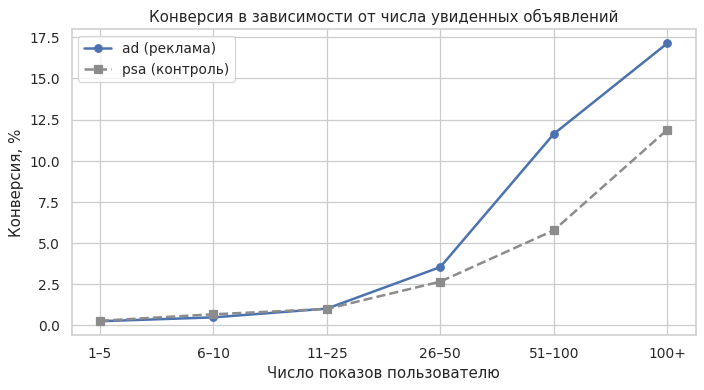

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(by_ads.index, by_ads['ad, %'], 'o-', color='#4C72B0', lw=2, label='ad (реклама)')
ax.plot(by_ads.index, by_ads['psa, %'], 's--', color='#8C8C8C', lw=2, label='psa (контроль)')
ax.set(title='Конверсия в зависимости от числа увиденных объявлений',
       xlabel='Число показов пользователю', ylabel='Конверсия, %')
ax.legend()
plt.tight_layout()
fig.savefig('images/exposure.png', dpi=120)
plt.show()


**Вывод по числу показов.** Здесь три важных наблюдения.

1. **Рост конверсии с числом показов виден в обеих группах**, в том числе в контроле (у `psa` от 0.3% до 11.9%). Значит, число показов в основном отражает *активность пользователя*, а не силу рекламы: активные люди видят больше объявлений и чаще покупают. Утверждать «чем больше показов, тем выше конверсия из-за рекламы» нельзя, и число показов пользователю не назначалось случайно.
2. **У пользователей, увидевших не больше 25 объявлений (73% аудитории), эффекта рекламы не обнаружено**: доверительные интервалы разницы включают ноль.
3. **Практически весь прирост даёт активная часть аудитории.** Пользователи с 26+ показами — это 27% группы `ad`, но на них приходится около 104% дополнительных покупок (знаки у малоактивных групп слегка отрицательные, но статистически неотличимы от нуля), в основном на пользователей с 51+ показами (около 86%).

Последний пункт — гипотеза, а не доказанный причинный эффект, потому что число показов определяется поведением пользователя. Проверить её можно только новым экспериментом, в котором **частота показов назначается случайно**.



## 9. Итоги и рекомендация

| Показатель | psa (контроль) | ad (реклама) | Результат |
|---|---|---|---|
| Конверсия | 1.79% | 2.55% | **+0.77 п.п. (+43%)**, 95% ДИ [0.60; 0.94] п.п. |
| Статистическая значимость | | | p ≈ 10⁻¹³, значимо |
| Дополнительных покупок | | | **≈4.3 тыс.** (≈30% покупок в группе ad), ДИ 3.4–5.3 тыс. |

**Рекомендация: кампанию стоит продолжать и масштабировать**, при условии что маржа с 7.7 дополнительных покупок на 1 000 пользователей превышает стоимость 1 000 показов. Реклама значимо повышает конверсию, результат устойчив к поправке на день недели и время суток и подтверждается бутстрепом.

**Что проверить дальше**
- **Частота показов.** Весь прирост сосредоточен у пользователей, увидевших много объявлений. Нужен эксперимент со случайно назначаемой частотой, чтобы понять, стоит ли показывать рекламу малоактивным пользователям.
- **Дни и время суток.** Сегменты с слабым эффектом (четверг, воскресенье) нужно перепроверить на большей контрольной группе.
- **Размер контроля.** При 4% пользователей в контрольной группе сегментный анализ шумный; в следующей волне стоит увеличить контроль, например до 10–20%.

**Ограничения**
- В данных нет стоимости показов и выручки, поэтому рентабельность (ROI) оценить нельзя.
- Группы немного различаются по распределению дней недели (например, четверг: 14.0% в `ad` и 16.6% в `psa`). Поправка на день и время суток результат не изменила.
- Число показов, день и час — характеристики, зафиксированные уже после начала кампании, поэтому причинные выводы о них делать нельзя.
- Нет информации о длительности кампании и о том, когда именно считалась конверсия.
